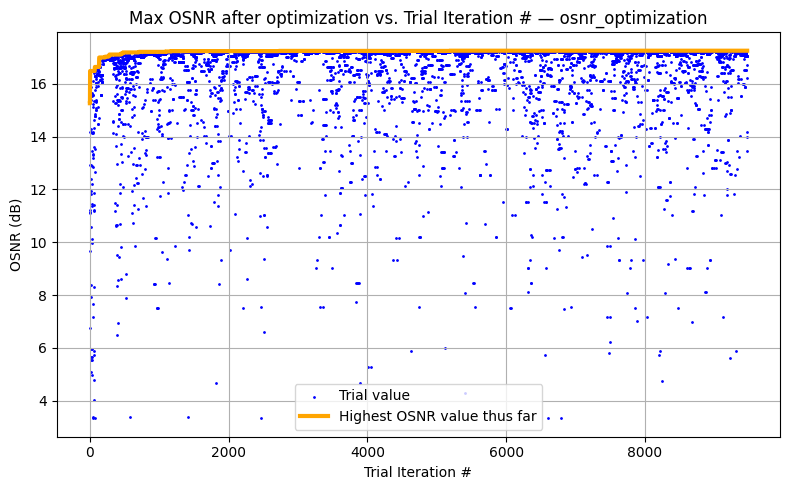

In [ ]:
import optuna
import matplotlib.pyplot as plt
import os
import sys

def main(db_path: str, study_name: str):
    # Construct the Optuna storage URL
    storage_url = f"sqlite:///{db_path}"
    
    # Load the study
    try:
        study = optuna.load_study(study_name=study_name, storage=storage_url)
    except Exception as e:
        print(f"Error loading study '{study_name}' from '{db_path}': {e}", file=sys.stderr)
        sys.exit(1)
    
    # Sort trials by trial number
    trials = sorted(study.trials, key=lambda t: t.number)
    trial_numbers = [t.number for t in trials]
    objective_values = [t.value for t in trials]
    
    # Determine best-so-far depending on maximize/minimize
    is_maximize = (study.direction == optuna.study.StudyDirection.MAXIMIZE)
    best_so_far = []
    if is_maximize:
        current_best = float("-inf")
        for v in objective_values:
            current_best = max(current_best, v)
            best_so_far.append(current_best)
    else:
        current_best = float("inf")
        for v in objective_values:
            current_best = min(current_best, v)
            best_so_far.append(current_best)
    
    # Plot scatter of each trial's value
    plt.figure(figsize=(8, 5))
    plt.scatter(trial_numbers,
                objective_values,
                color='blue',
                s=1,           # dot size in points^2
                label='Trial value')
    
    # Plot best-so-far as an orange line, no markers
    plt.plot(trial_numbers,
             best_so_far,
             color='orange',
             linewidth=3,  # medium thickness (1.5 pt)
             label='Highest OSNR value thus far')
    
    plt.xlabel("Trial Iteration #")
    plt.ylabel("OSNR (dB)")
    plt.title(f"{'Max' if is_maximize else 'Min'} OSNR after optimization vs. Trial Iteration #")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    DB_PATH = "optuna_study.db"
    STUDY_NAME = "osnr_optimization"
    
    if not os.path.isfile(DB_PATH):
        print(f"Database file not found: {DB_PATH}", file=sys.stderr)
        sys.exit(1)
    
    main(DB_PATH, STUDY_NAME)
